Shape: (300, 4)
       pengalaman     edu    gaji
count      300.00  300.00  300.00
mean         9.90    0.89   27.40
std          5.89    0.83   13.41
min          0.10    0.00    1.67
25%          4.78    0.00   16.24
50%         10.23    1.00   27.97
75%         15.14    2.00   38.89
max         19.80    2.00   54.22


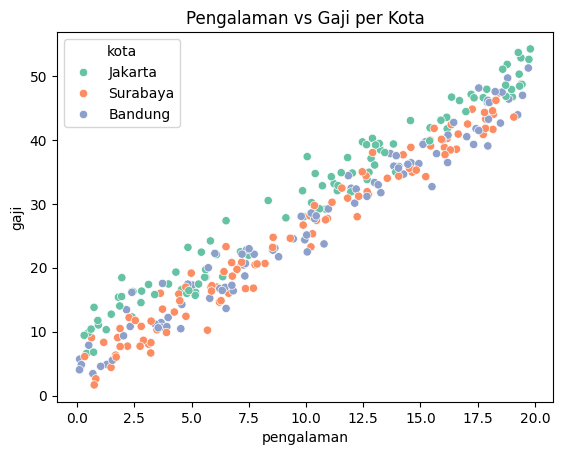

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

n = 300

pengalaman = np.random.uniform(0, 20, n)
edu = np.random.choice([0, 1, 2], n)
kota = np.random.choice(
    ['Jakarta', 'Surabaya', 'Bandung'],
    n
)

gaji = (
    3.0
    + 2.2 * pengalaman
    + 1.5 * edu
    + np.where(kota == 'Jakarta', 4.0, 0)
    + np.random.normal(0, 2, n)
)

df = pd.DataFrame({
    'pengalaman': pengalaman,
    'edu': edu,
    'kota': kota,
    'gaji': gaji
})

print('Shape:', df.shape)
print(df.describe().round(2))

sns.scatterplot(
    data=df,
    x='pengalaman',
    y='gaji',
    hue='kota',
    palette='Set2'
)

plt.title('Pengalaman vs Gaji per Kota')
plt.show()

In [67]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.get_dummies(
    df,
    columns=['kota'],
    drop_first=True,
    dtype=int
)

print(df.columns.tolist())

X = df.drop('gaji', axis=1)
y = df['gaji']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(
    f'Train: {X_train.shape[0]} baris, '
    f'Test: {X_test.shape[0]} baris'
)

scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

['pengalaman', 'edu', 'gaji', 'kota_Jakarta', 'kota_Surabaya']
Train: 240 baris, Test: 60 baris


In [68]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(
    X_train_s,
    y_train
)

print(
    f'β₀ (intercept): '
    f'{model.intercept_:.3f}'
)

coef_df = pd.DataFrame({
    'Fitur': X.columns,
    'Koefisien': model.coef_.round(3)
})

coef_df = coef_df.sort_values(
    'Koefisien',
    ascending=False
)

print(coef_df.to_string(index=False))

β₀ (intercept): 27.514
        Fitur  Koefisien
   pengalaman     13.042
 kota_Jakarta      1.837
          edu      1.188
kota_Surabaya     -0.292


In [69]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

y_pred = model.predict(X_test_s)

mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2 = r2_score(
    y_test,
    y_pred
)

print('=== Metrik Evaluasi ===')

print(
    f'MAE = {mae:.3f} juta rupiah'
)

print(
    f'RMSE = {rmse:.3f} juta rupiah'
)

print(
    f'R² = {r2:.4f}'
)

print(
    f'Selisih RMSE-MAE = {rmse-mae:.3f}'
)

=== Metrik Evaluasi ===
MAE = 1.649 juta rupiah
RMSE = 2.123 juta rupiah
R² = 0.9740
Selisih RMSE-MAE = 0.474


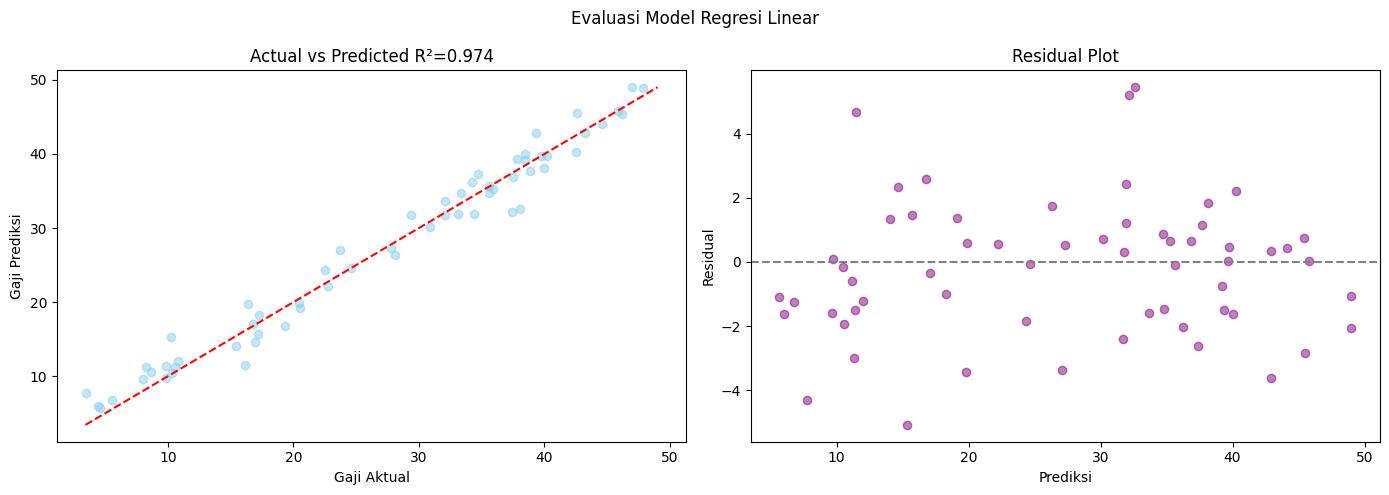

In [70]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(14,5)
)

axes[0].scatter(
    y_test,
    y_pred,
    alpha=0.5,
    color='skyblue'
)

lims = [
    min(y_test.min(), y_pred.min()),
    max(y_test.max(), y_pred.max())
]

axes[0].plot(
    lims,
    lims,
    'r--'
)

axes[0].set_xlabel(
    'Gaji Aktual'
)

axes[0].set_ylabel(
    'Gaji Prediksi'
)

axes[0].set_title(
    f'Actual vs Predicted R²={r2:.3f}'
)

residuals = y_test - y_pred

axes[1].scatter(
    y_pred,
    residuals,
    alpha=0.5,
    color='purple'
)

axes[1].axhline(
    0,
    color='gray',
    linestyle='--'
)

axes[1].set_xlabel(
    'Prediksi'
)

axes[1].set_ylabel(
    'Residual'
)

axes[1].set_title(
    'Residual Plot'
)

plt.suptitle(
    'Evaluasi Model Regresi Linear'
)

plt.tight_layout()

plt.savefig(
    'evaluasi_regresi.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()